In [1]:
import zipfile
import os

# Path to your ZIP file
zip_path = r'C:/Users/HP/Downloads/balanced_labeled_photos.zip'
extract_path = r'yelp_photos'  # where to extract

# Unzip
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

# Check folders
print("Extracted folders:", os.listdir(extract_path))


Extracted folders: ['balanced_labeled_photos', 'Dataset_User_Agreement.pdf', 'photos', 'photos.json']


In [2]:
import os

data_root = "yelp_photos"

print("Contents of data root:", os.listdir(data_root))
print("Contents of balanced_labeled_photos:", os.listdir(os.path.join(data_root, "balanced_labeled_photos")))
print("Contents of photos:", os.listdir(os.path.join(data_root, "photos")))


Contents of data root: ['balanced_labeled_photos', 'Dataset_User_Agreement.pdf', 'photos', 'photos.json']
Contents of balanced_labeled_photos: ['drink', 'food', 'inside', 'menu', 'outside']


IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



In [5]:
import os

data_root = "yelp_photos"
folder = "balanced_labeled_photos"
full_path = os.path.join(data_root, folder)

# List only first 10 files from each class folder
for class_folder in os.listdir(full_path):
    class_path = os.path.join(full_path, class_folder)
    files = os.listdir(class_path)
    print(f"Class '{class_folder}' has {len(files)} images. Here are 10 samples:")
    print(files[:10])


Class 'drink' has 15670 images. Here are 10 samples:
['--puCF1Lauwb3k6vrVVvfQ.jpg', '--y-d0b4_JQeKv7Yz39_Kw.jpg', '-0-Sor-tVeKH_KXSWI8SMw.jpg', '-03jEudW-0CXZhRhY9j3cg.jpg', '-07rvFvU6UOTuSEGa6HR9A.jpg', '-1h8RaVNoRDMJ1TuR--UPw.jpg', '-1wBDCpkQRt0X4QqhO5uMw.jpg', '-26yvqotk0rqT6OFGXTaOw.jpg', '-3-BFGlvZS2GA1yxdqm3Mw.jpg', '-32lR19VYAZQok6Z8tN_9w.jpg']
Class 'food' has 20000 images. Here are 10 samples:
['--3JQ4MlO-jHT9xbo7liug.jpg', '--9cH8_rrskfmYvONaJpgQ.jpg', '--j4xVIdIlYpOmZbs7iszg.jpg', '--wxyCFpNg13pVl00xvlXg.jpg', '--zScnI03KioBVMtcOK6oQ.jpg', '-0A6_xM5K-YK8wwnGgBpEQ.jpg', '-0fa0mOVKrJW90MFFxVImg.jpg', '-0l6FrIjTVo8x92V0XBTZA.jpg', '-0SNYNp7RKMuGqSc_Rycqg.jpg', '-10Ge63S6TdapDZV5ZGJLw.jpg']
Class 'inside' has 20000 images. Here are 10 samples:
['--4DfhW2sJvjeC90KEDX3g.jpg', '--7SiWWk_OHbdmcU4pNDQw.jpg', '--AU_cPMgrWSPluP1v8n_Q.jpg', '--dacvi4Y_8ACp-10nafMA.jpg', '--e8vgtonVwPXG3n6lfBLA.jpg', '--gjH9oA92f7OuTSovXjCg.jpg', '--kP__1IcWsQE0ycWKT0bg.jpg', '--WioehVQHeKzop8t3_8Bw.jpg'

In [6]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt

# Path to your image folder with subfolders (classes)
data_dir = "yelp_photos/balanced_labeled_photos"

# Parameters
img_size = (128, 128)
batch_size = 32


In [7]:
datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

train_gen = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

val_gen = datagen.flow_from_directory(
    data_dir,
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)


Found 75392 images belonging to 5 classes.
Found 18847 images belonging to 5 classes.


In [8]:
model = models.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(train_gen.num_classes, activation='softmax')  # number of classes dynamically from train_gen
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │       3,211,392 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 5)                   │             645 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,305,285 (12.61 MB)

 Trainable params: 3,305,285 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = model.fit(
    train_gen,
    epochs=10,
    validation_data=val_gen
)


C:\Users\HP\anaconda3\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 2312s 979ms/step - accuracy: 0.6955 - loss: 0.7909 - val_accuracy: 0.8872 - val_loss: 0.3325
Epoch 2/10
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 575s 244ms/step - accuracy: 0.8727 - loss: 0.3708 - val_accuracy: 0.8868 - val_loss: 0.3100
Epoch 3/10
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 577s 245ms/step - accuracy: 0.9016 - loss: 0.2833 - val_accuracy: 0.9052 - val_loss: 0.2810
Epoch 4/10
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 575s 244ms/step - accuracy: 0.9175 - loss: 0.2345 - val_accuracy: 0.9073 - val_loss: 0.2649
Epoch 5/10
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 578s 245ms/step - accuracy: 0.9302 - loss: 0.1947 - val_accuracy: 0.9218 - val_loss: 0.2419
Epoch 6/10
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 529s 224ms/step - accuracy: 0.9410 - loss: 0.1635 - val_accuracy: 0.9245 - val_loss: 0.2445
Epoch 7/10
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 515s 218ms/step - accuracy: 0.9505 - loss: 0.1396 - val_accuracy: 0.9196 - val_loss: 0.2755
Epoch 8/10
2356/2356 ━━━━━━━━━━━━━━━━━━━━ 605s 257ms/step - a

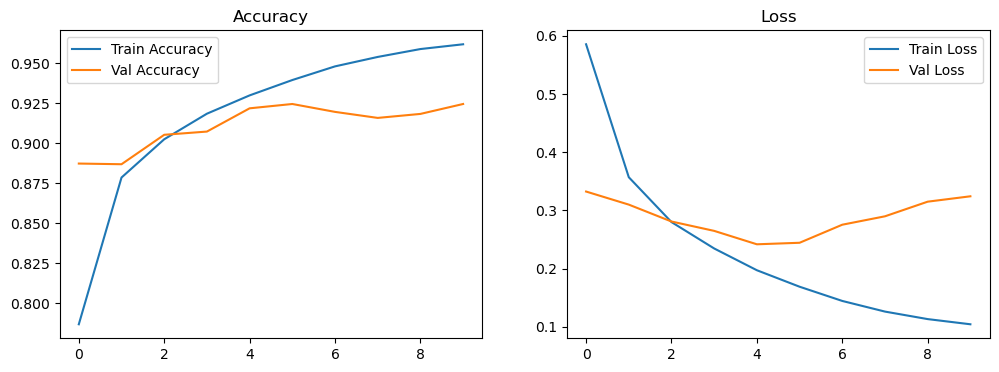

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.show()


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping

model = models.Sequential([
    layers.Input(shape=(img_size[0], img_size[1], 3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.6),

    layers.Dense(train_gen.num_classes, activation='softmax')
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[early_stopping]
)


Epoch 1/30
1170/2356 ━━━━━━━━━━━━━━━━━━━━ 7:09 362ms/step - accuracy: 0.4464 - loss: 1.7482